# Notebook 1C. Pre-trained Convolutional Neural Networks (CNN)
---

Organized and prepared by Christopher Monterola, updated by Kenneth Co.

This notebook was conceptualized, organized, and primarily prepared for the **Machine Learning** courses.

### This notebook uses the following references:
Lecture is organized and compiled/taken from:
1. Python Machine Learning, Second Edition, Sebastian Raschka and Vahid Mirjalili, Packt Publishing Ltd. Birmingham B3 2PB, UK Sept 2017.
2. Hands-On Machine Learning with Scikit-Learn and TensorFlow, Aurélien Géron, O'Reilly 2017.
3. Deep Learning with Python, Francois Chollet, Manning New York 2018.
4. 2018 Google: https://colab.research.google.com/github/google/eng-edu/blob/master/ml/pc/exercises/image_classification_part1.ipynb

Again, here is a list of data available for potential individual mini projects: https://en.wikipedia.org/wiki/List_of_datasets_for_machine_learning_research

---

From 70-73%, we previously demonstrated how data augmentation improves the accuracy up to 83%. In this notebook, we show that book the speed and accuracy can further be enhanced by using pre-trained CNN.

## Google Colab Setup

In [1]:
# !pip install -U keras
# !pip install -U tensorflow

In [2]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/COSCI224 Machine Learning 3 Notebooks/data/'
IMG_DIR = '/content/drive/MyDrive/COSCI224 Machine Learning 3 Notebooks/images/'
MODEL_DIR = '/content/drive/MyDrive/COSCI224 Machine Learning 3 Notebooks/models/'

# DATA_DIR = 'data/'
# IMG_DIR = 'images/'
# MODEL_DIR = 'models/'

Mounted at /content/drive


Working with pre-trained models may take longer when using the CPU alone. Hence, we enable GPU or TPU on Google Colab.

First, enable GPUs for the notebook:
1. Navigate to ```Edit → Notebook Settings``` in the toolbar.
2. Select ```GPU``` from the Hardware Accelerator drop-down.

Next, verify if GPU is enabled. You will know this by running the code script below. It should show that a GPU is recognized.

In [3]:
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  raise SystemError('GPU device not found')
print('Found GPU at: {}'.format(device_name))

Found GPU at: /device:GPU:0


# Why pre-trained CNNs?
---

Using a pre-trained network is a common and highly effective approach to deep learning on small image datasets. A pre-trained network is a saved network previously trained on a large dataset, typically on a large-scale image-classification task. **If this original dataset is large enough and general enough, then the spatial hierarchy of features learned by the pre-trained network can effectively act as a generic model of the visual world, and hence, its features can prove useful for many different computer vision problems,** even though these new problems may involve completely different classes than those of the original task. For instance, you might train a network on ImageNet (where classes are mostly animals and everyday objects) and then repurpose this trained network for something as remote as identifying furniture items in images.

Such portability of learned features across different problems is a key advantage of deep learning compared to many older, shallow-learning approaches, and it makes deep learning very effective even for small-data problems. In this case, let’s consider a large CNN trained on the [ImageNet dataset](https://en.wikipedia.org/wiki/ImageNet) (1.4 million labeled images and 1,000 different classes). ImageNet contains many animal classes, including different species of cats and dogs, and you can thus expect to perform well on the dogs-versus-cats classification problem.

You’ll use the VGG16 architecture, developed by Karen Simonyan and Andrew Zisserman in 2014; it’s a simple and widely used convnet architecture for ImageNet: [Karen Simonyan and Andrew Zisserman, “Very Deep Convolutional Networks for Large-Scale Image Recognition,” arXiv (2014)](https://arxiv.org/abs/1409.1556). Although it’s an older model, far from the current state of the art and somewhat heavier than many other recent models, I chose it because its architecture is similar to what you’re already familiar with and is easy to understand without introducing any new concepts. This may be your first encounter with one of these cutesy model names—VGG, ResNet, Inception, Inception-ResNet, Xception, and so on; you’ll get used to them, because they will come up frequently if you keep doing deep learning for computer vision. There are two ways to use a pretrained network: feature extraction and fine-tuning.

Let’s start with feature extraction.

# Step 1. Feature Extraction

Feature extraction consists of using the representations learned by a previous network to extract interesting features from new samples. These features are then run through a new classifier, which is trained from scratch.
As you saw previously, convnets used for image classification comprise two parts:
they start with a series of pooling and convolution layers, and they end with a densely
connected classifier. The first part is called the convolutional base of the model. In the
case of convnets, feature extraction consists of taking the convolutional base of a previously trained network, running the new data through it, and training a new classifier on top of the output (see figure below).

<img width="500" alt="swapping_classifiers" src="https://user-images.githubusercontent.com/25600601/134777359-711c0dec-ed92-4910-8370-6d877fe4609b.png">

Why only reuse the convolutional base? Could you reuse the densely connected classifier as well? **In general, doing so should be avoided. The reason is that the representations learned by the convolutional base are likely to be more generic and therefore more reusable:** the feature maps of a convnet are presence maps of generic concepts over a picture, which is likely to be useful regardless of the computer-vision problem at hand. But the representations learned by the classifier will necessarily be specific to the set of classes on which the model was trained—they will only contain information about the presence probability of this or that class in the entire picture. Additionally, representations found in densely connected layers no longer contain any information about where objects are located in the input image: these layers get rid of the notion of space, whereas the object location is still described by convolutional feature maps. For problems where object location matters, densely connected features are largely useless. Note that the level of generality (and therefore reusability) of the representations
extracted by specific convolution layers depends on the depth of the layer in the model. Layers that come earlier in the model extract local, highly generic feature maps (such as visual edges, colors, and textures), whereas layers that are higher up extract more-abstract concepts (such as “cat ear” or “dog eye”). So if your new dataset differs a lot from the dataset on which the original model was trained, you may be better off using only the first few layers of the model to do feature extraction, rather than using the entire convolutional base.

In this case, because the ImageNet class set contains multiple dog and cat classes, it’s likely to be beneficial to reuse the information contained in the densely connected layers of the original model. But we’ll choose not to, in order to cover the more general case where the class set of the new problem doesn’t overlap the class set of the original model. Let’s put this in practice by using the convolutional base of the VGG16 network, trained on ImageNet, to extract interesting features from cat and dog images, and then train a dogs-versus-cats classifier on top of these features.

The VGG16 model, among others, comes prepackaged with Keras. You can import it from the keras.applications module. Here’s the list of image-classification models (all pretrained on the ImageNet dataset) that are available as part of *keras.applications*:
- Xception   
- Inception V3   
- ResNet50  
- VGG16  
- VGG19  
- MobileNet  

In 2014, 16 and 19 layer networks were considered very deep (although we now have the ResNet architecture which can be successfully trained at depths of 50-200 for ImageNet and over 1,000 for CIFAR-10). Simonyan and Zisserman found training VGG16 and VGG19 challenging (specifically regarding convergence on the deeper networks), so in order to make training easier, they first trained smaller versions of VGG with less weight layers (columns A and C) first.

The smaller networks converged and were then used as initializations for the larger, deeper networks — this process is called *pre-training*.

While making logical sense, pre-training is a very time consuming, tedious task, requiring an entire network to be trained before it can serve as an initialization for a deeper network.

Let’s instantiate the VGG16 model or OxfordNet. VGG means Visual Geometry Group from Oxford with 16 layers as shown below:

<img width="800" alt="VGG16" src="https://user-images.githubusercontent.com/25600601/134777383-0be97327-da9d-42d0-b98c-751599ec7b3d.png">

The 16 layers are:
1. Convolution using 64 filters
2. Convolution using 64 filters + Max pooling
3. Convolution using 128 filters
4. Convolution using 128 filters + Max pooling
5. Convolution using 256 filters
6. Convolution using 256 filters
7. Convolution using 256 filters + Max pooling
8. Convolution using 512 filters
9. Convolution using 512 filters
10. Convolution using 512 filters + Max pooling
11. Convolution using 512 filters
12. Convolution using 512 filters
13. Convolution using 512 filters + Max pooling
14. Fully connected with 4096 nodes
15. Fully connected with 4096 nodes
16. Output layer with Softmax activation with 4096(above figure) or 1000 (below figure) nodes

<img width="800" alt="VGG16_fullview" src="https://user-images.githubusercontent.com/25600601/134777407-4e99ec7b-cad7-440a-bb06-5c7d01c55491.png">

## Step 1A. Instantiate the VGG16 convolutional base

In [4]:
from tensorflow.keras.applications import VGG16

conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(150, 150, 3))

58889256/58889256 [==============================] - 0s 0us/step


You pass three arguments to the constructor:
- `weights` specifies the weight checkpoint from which to initialize the model.

- `include_top` refers to including (or not) the densely connected classifier on top of the network. By default, this densely connected classifier corresponds to the 1,000 classes from ImageNet. Because you intend to use your own densely connected classifier (with only two classes: cat and dog), you don't need to include it.

- `input_shape` is the shape of the image tensors that you'll feed to the network. This argument is purely optional: if you don't pass it, the network will be able to process inputs of any size.

Here's the detail of the architecture of the VGG16 convolutional base. It's similar to the simple convnets you're already familiar with:

In [5]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

The final feature map has shape (4, 4, 512). That's the feature on top of which you'll stick a densely connected classifier.

At this point, there are two ways you could proceed:

1. Running the convolutional base over your dataset, recording its output to a Numpy array on disk, and then using this data as input to a standalone, densely connected classifier similar to those you saw in part 1 of this book. This solution is fast and cheap to run, because it only requires running the convolutional base once for every input image, and the convolutional base is by far the most expensive part of the pipeline. But for the same reason, this technique won't allow you to use data augmentation.

2. Extending the model you have `conv_base` by adding Dense layers on top, and running the whole thing end to end on the input data. This will allow you to use data augmentation, because every input image goes through the convolutional base every time it's seen by the model. But for the same reason, this technique is far more expensive than the first. We'll cover both techniques. Let's walk through the code required to set up the first
one: recording the output of `conv_base` on your data and using these outputs as inputs to a new model.

## Step 1B. Fast feature extraction without Data Augmentation

You’ll start by running instances of the previously introduced ImageDataGenerator to extract images as Numpy arrays as well as their labels. You’ll extract features from these images by calling the predict method of the *conv_base* model.

### Extracting features using the pretrained convolutional base

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [7]:
_URL = 'https://storage.googleapis.com/mledu-datasets/cats_and_dogs_filtered.zip'
zip_dir = tf.keras.utils.get_file('cats_and_dogs_filterted.zip', origin=_URL, extract=True)

68606236/68606236 [==============================] - 1s 0us/step


In [8]:
base_dir = os.path.join(os.path.dirname(zip_dir), 'cats_and_dogs_filtered')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

Let's look at how many cats and dogs images we have in our training and validation directory

In [9]:
train_cats_dir = os.path.join(train_dir, 'cats')  # directory with our training cat pictures
train_dogs_dir = os.path.join(train_dir, 'dogs')  # directory with our training dog pictures
validation_cats_dir = os.path.join(validation_dir, 'cats')  # directory with our validation cat pictures
validation_dogs_dir = os.path.join(validation_dir, 'dogs')  # directory with our validation dog pictures


In [10]:
num_cats_tr = len(os.listdir(train_cats_dir))
num_dogs_tr = len(os.listdir(train_dogs_dir))

num_cats_val = len(os.listdir(validation_cats_dir))
num_dogs_val = len(os.listdir(validation_dogs_dir))

total_train = num_cats_tr + num_dogs_tr
total_val = num_cats_val + num_dogs_val

In [11]:
print('total training cat images:', num_cats_tr)
print('total training dog images:', num_dogs_tr)

print('total validation cat images:', num_cats_val)
print('total validation dog images:', num_dogs_val)
print("--")
print("Total training images:", total_train)
print("Total validation images:", total_val)

total training cat images: 1000
total training dog images: 1000
total validation cat images: 500
total validation dog images: 500
--
Total training images: 2000
Total validation images: 1000


In [12]:
import os
import numpy as np
from keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255)
batch_size = 20

def extract_features(directory, sample_count):
    features = np.zeros(shape=(sample_count, 4, 4, 512))
    labels = np.zeros(shape=(sample_count))
    generator = datagen.flow_from_directory(
        directory,
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')
    i = 0
    for inputs_batch, labels_batch in generator:
        features_batch = conv_base.predict(inputs_batch)   #Call the conv_base
        features[i * batch_size : (i + 1) * batch_size] = features_batch
        labels[i * batch_size : (i + 1) * batch_size] = labels_batch
        i += 1
        if i * batch_size >= sample_count:
            break
    return features, labels

train_features, train_labels = extract_features(train_dir, 2000)
validation_features, validation_labels = extract_features(validation_dir, 1000)
#test_features, test_labels = extract_features(test_dir, 1000)

Found 2000 images belonging to 2 classes.
1/1 [==============================] - 0s 28ms/step
Found 1000 images belonging to 2 classes.
1/1 [==============================] - 0s 31ms/step


The extracted features are currently of shape (samples, 4, 4, 512). You’ll feed them to a densely connected classifier, so first you must flatten them to (samples, 8192):

In [13]:
train_features = np.reshape(train_features, (2000, 4 * 4 * 512))
validation_features = np.reshape(validation_features, (1000, 4 * 4 * 512))
#test_features = np.reshape(test_features, (1000, 4 * 4 * 512))

In [14]:
len(train_features[0])

8192

In [15]:
sum(validation_labels)

500.0

At this point, you can define your densely connected classifier (note the use of dropout
for regularization) and train it on the data and labels that you just recorded.

# Step 2. Define and train the densely connected classifier

In [16]:
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_dim=4 * 4 * 512))
model.add(layers.Dropout(0.5))  #Removing 50% of the weights every batch iteration!
model.add(layers.Dense(1, activation='sigmoid'))

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 2097665 (8.00 MB)
Trainable params: 2097665 (8.00 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
model.compile(optimizer=optimizers.RMSprop(lr=2e-5),
              loss='binary_crossentropy',
              metrics=['acc'])
history = model.fit(train_features, train_labels,
                    epochs=50,
                    batch_size=20,
                    validation_data=(validation_features, validation_labels))

Epoch 1/50
100/100 [==============================] - 3s 7ms/step - loss: 0.7927 - acc: 0.7390 - val_loss: 0.3184 - val_acc: 0.8500
Epoch 2/50
100/100 [==============================] - 0s 4ms/step - loss: 0.3549 - acc: 0.8590 - val_loss: 0.3246 - val_acc: 0.8550
Epoch 3/50
100/100 [==============================] - 0s 4ms/step - loss: 0.2793 - acc: 0.8800 - val_loss: 0.2845 - val_acc: 0.8820
Epoch 4/50
100/100 [==============================] - 0s 4ms/step - loss: 0.2408 - acc: 0.9005 - val_loss: 0.2627 - val_acc: 0.8750
Epoch 5/50
100/100 [==============================] - 0s 4ms/step - loss: 0.2175 - acc: 0.9150 - val_loss: 0.2995 - val_acc: 0.8770
Epoch 6/50
100/100 [==============================] - 0s 4ms/step - loss: 0.1959 - acc: 0.9245 - val_loss: 0.5316 - val_acc: 0.8270
Epoch 7/50
100/100 [==============================] - 0s 4ms/step - loss: 0.1618 - acc: 0.9365 - val_loss: 0.3526 - val_acc: 0.8760
Epoch 8/50
100/100 [==============================] - 0s 4ms/step - loss: 0.

Training is very fast, because you only have to deal with two Dense layers—an epoch takes less than one second even on CPU. Let’s look at the loss and accuracy curves during training (see below)

# Step 3. Plot the results

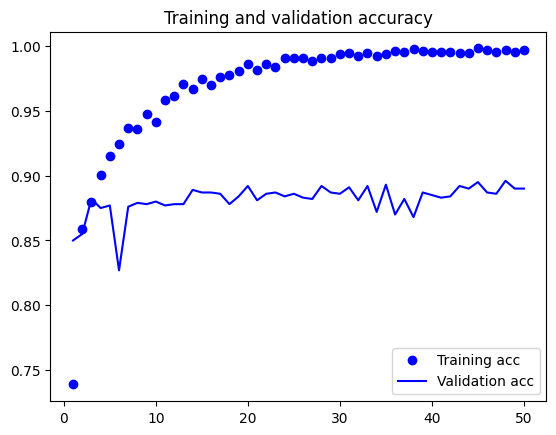

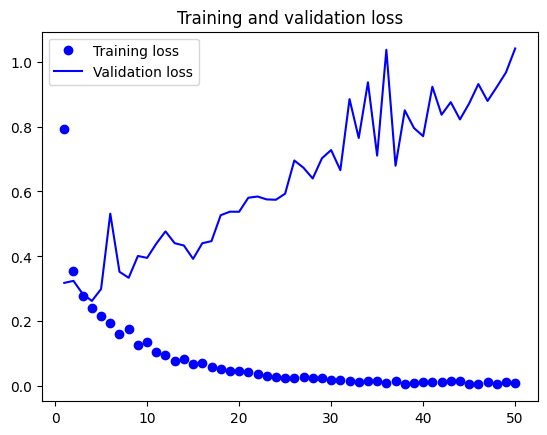

In [19]:
import matplotlib.pyplot as plt
%matplotlib inline

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

You reach a validation accuracy of about 90%—much better than you achieved previously with the small model trained from scratch. But the plots also indicate that you’re overfitting almost from the start—despite using dropout with a fairly large rate. That’s because this technique doesn’t use data augmentation, which is essential for preventing overfitting with small image datasets.

<div class="alert alert-block alert-success">

### Recap of Model Performance
1. Small CNN (70-73%)
2. Small CNN + Data Augmentation and Dropout (83%)
3. VGG16 with frozen Dense Layer (90%)

</div>

## Saving and Testing the Model

In [22]:
# serialize/save model architecture to JSON
model_json = model.to_json()
with open(MODEL_DIR + "model_fastCNN.json", "w") as json_file:
    json_file.write(model_json)

# serialize/save weights to HDF5
model.save_weights(MODEL_DIR + "model_fastCNN.h5")
print("Saved model to disk")

Saved model to disk


In [23]:
from tensorflow.keras.models import model_from_json

# Model reconstruction from JSON file
with open(MODEL_DIR + "model_fastCNN.json", "r") as f:
    model = model_from_json(f.read())


In [24]:
from tensorflow.keras.models import load_model
model.load_weights(MODEL_DIR +"model_fastCNN.h5")

In [28]:
from PIL import Image
%matplotlib inline
from tensorflow.keras.layers import Input, Flatten

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

img_path =  IMG_DIR + 'mycat_blue.png'

img = image.load_img(img_path, target_size=(150, 150))

#ImageDataGenerator(rescale=1./255)
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)
y=conv_base.predict(x)
z=Flatten()(y)

#CAT =0, DOG =1
Prediction = model.predict(z)
if Prediction >= .5:
    print("DOG")
else:
    print("CAT")

print(Prediction)

img = Image.open(img_path)
img

Output hidden; open in https://colab.research.google.com to view.

# Step 4. (SLOW) Feature extraction with data augmentation
Now, let’s review the second technique I mentioned for doing feature extraction, which is much slower and more expensive, but which allows you to use data augmentation during training: extending the conv_base model and running it end to end on the inputs.

<div class="alert alert-block alert-warning">

**NOTE: This technique is so expensive that if you can't run your code on GPU, then the previous technique is the way to go.**

</div>

Because models behave just like layers, you can add a model (like conv_base) to a Sequential model just like you would add a layer.

## Step 4A. Add a densely connected classifier on top of the convolutional base

In [29]:
from tensorflow.keras import models
from tensorflow.keras import layers
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

This is what the model looks like now:

In [30]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 flatten_2 (Flatten)         (None, 8192)              0         
                                                                 
 dense_2 (Dense)             (None, 256)               2097408   
                                                                 
 dense_3 (Dense)             (None, 1)                 257       
                                                                 
Total params: 16812353 (64.13 MB)
Trainable params: 16812353 (64.13 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


As you can see, the convolutional base of VGG16 has 14,714,688 parameters, which is very large. The classifier you’re adding on top has 2 million parameters.

Before you compile and train the model, it’s very important to freeze the convolutional base. Freezing a layer or set of layers means preventing their weights from being updated during training. If you don’t do this, then the representations that were previously learned by the convolutional base will be modified during training. Because the Dense layers on top are randomly initialized, very large weight updates would be propagated through the network, effectively destroying the representations previously
learned.

In Keras, you freeze a network by setting its trainable attribute to False:

In [31]:
print('This is the number of trainable weights before freezing the conv base:', len(model.trainable_weights))
conv_base.trainable = False
print('This is the number of trainable weights after freezing the conv base:', len(model.trainable_weights))

This is the number of trainable weights before freezing the conv base: 30
This is the number of trainable weights after freezing the conv base: 4


With this setup, only the weights from the two Dense layers that you added will be trained. That’s a total of four weight tensors: two per layer (the main weight matrix and the bias vector). Note that in order for these changes to take effect, you must first compile the model. If you ever modify weight trainability after compilation, you
should then recompile the model, or these changes will be ignored.

Now you can start training your model, with the same data-augmentation configuration that you used in the previous example. This will take a very long time if you will not run this using GPU, see example below!

## Step 4B.  Training the model end to end with a frozen convolutional base

In [32]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
#from keras.utils import multi_gpu_model

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

model.compile(loss='binary_crossentropy',
    optimizer=optimizers.RMSprop(lr=2e-5),
    metrics=['acc'])

#history = model_gpu.fit_generator(
history = model.fit(
    train_generator,
    steps_per_epoch=100,
    epochs=50,
    validation_data=validation_generator,
    validation_steps=50,
    max_queue_size=30,
    use_multiprocessing=False,
 #   workers=24
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Epoch 1/50
100/100 [==============================] - 20s 192ms/step - loss: 0.7900 - acc: 0.6970 - val_loss: 0.3863 - val_acc: 0.8120
Epoch 2/50
100/100 [==============================] - 20s 199ms/step - loss: 0.4644 - acc: 0.7840 - val_loss: 0.4385 - val_acc: 0.8030
Epoch 3/50
100/100 [==============================] - 19s 186ms/step - loss: 0.3965 - acc: 0.8125 - val_loss: 0.3004 - val_acc: 0.8700
Epoch 4/50
100/100 [==============================] - 19s 188ms/step - loss: 0.3952 - acc: 0.8140 - val_loss: 0.3474 - val_acc: 0.8580
Epoch 5/50
100/100 [==============================] - 21s 210ms/step - loss: 0.3683 - acc: 0.8335 - val_loss: 0.4934 - val_acc: 0.7960
Epoch 6/50
100/100 [==============================] - 19s 189ms/step - loss: 0.3558 - acc: 0.8470 - val_loss: 0.2775 - val_acc: 0.8940
Epoch 7/50
100/100 [==============================] - 19s 187ms/step - loss: 0.3472 - acc: 0.8470 - val_loss: 0.3308 - val_acc: 0.8660
Epoch 8/50
100/100 [==============================] - 1

<div class="alert alert-block alert-success">

### ⚠️ Checkpoint ⚠️

**Recap of Model Performance**
1. Small CNN (70-73%)
2. Small CNN + Data Augmentation and Dropout (83%)
3. VGG16 with frozen Dense Layer (90%)
4. VGG16 with frozen Dense Layer trained end to end with Data Augmentation (90%)

Plotting the results again, we see that you reach a validation accuracy of about 90% which is almost the same as the previous method without data augmentation. WHY?
</div>

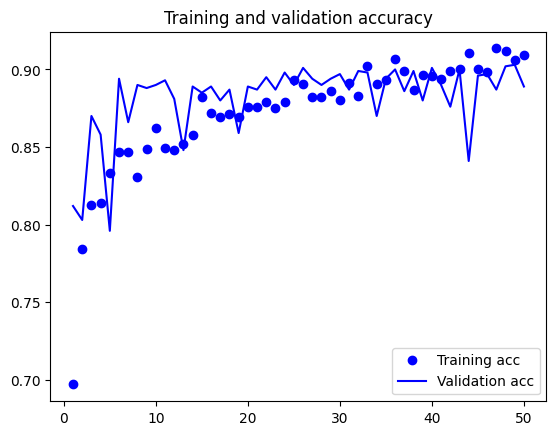

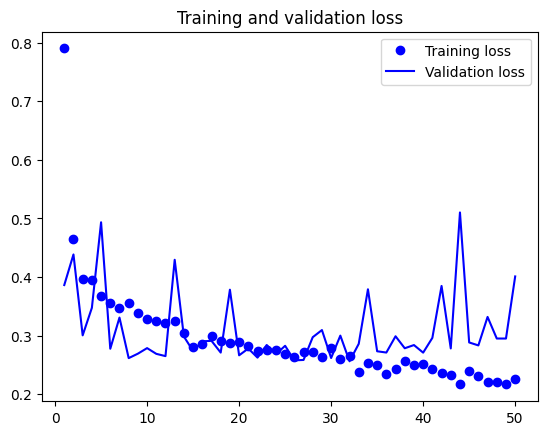

In [33]:
import matplotlib.pyplot as plt
%matplotlib inline

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [34]:
#test_generator = test_datagen.flow_from_directory(
#    test_dir,
#    target_size=(150, 150),
#    batch_size=20,
#    class_mode='binary')

#test_loss, test_acc = model.evaluate_generator(test_generator, steps=50)
#print('test acc:', test_acc)

# Step 5: Fine Tuning

Another widely used technique for model reuse, complementary to feature extraction, is fine-tuning. Fine-tuning consists of unfreezing a few of the top layers of a frozen model base used for feature extraction, and jointly training both the newly added part of the model (in this case, the fully connected classifier) and these top layers. This is called fine-tuning because it slightly adjusts the more abstract representations of the model being reused, in order to make them more relevant for the problem at hand.

<img width="180" alt="fine_tuning" src="https://user-images.githubusercontent.com/25600601/134777551-3bde69f6-03e8-4dc5-81a8-3616695ea0bc.png">


We have stated earlier that it’s necessary to freeze the convolution base of VGG16 in order to be able to train a randomly initialized classifier on top. For the same reason, it’s only possible to fine-tune the top layers of the convolutional base once the classifier on top has already been trained. If the classifier isn’t already trained, then the error signal propagating through the network during training will be too large, and the representations
previously learned by the layers being fine-tuned will be destroyed. Thus the steps for fine-tuning a network are as follow:

1 Add your custom network on top of an already-trained base network.    
2 Freeze the base network.   
3 Train the part you added.   
4 Unfreeze some layers in the base network.   
5 Jointly train both these layers and the part you added.   

You already completed the first three steps when doing feature extraction. Let’s proceed with step 4: you’ll unfreeze your conv_base and then freeze individual layers inside it.

As a reminder, this is what your convolutional base looks like:

In [35]:
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

You’ll fine-tune the last three convolutional layers, which means all layers up to block4_pool should be frozen, and the layers block5_conv1, block5_conv2, and block5_conv3 should be trainable.

Why not fine-tune more layers? Why not fine-tune the entire convolutional base? You could. But you need to consider the following:

 Earlier layers in the convolutional base encode more-generic, reusable features, whereas layers higher up encode more-specialized features. It’s more useful to fine-tune the more specialized features, because these are the ones that need to be repurposed on your new problem. There would be fast-decreasing returns in fine-tuning lower layers.

 The more parameters you’re training, the more you’re at risk of overfitting. The convolutional base has 15 million parameters, so it would be risky to attempt to train it on your small dataset. Thus, in this situation, it’s a good strategy to fine-tune only the top two or three layers in the convolutional base. Let’s set this up, starting from where you left off in the previous example.

## Step 5A. Freezing all layers up to a specific one

In [36]:
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
    if layer.name == 'block5_conv1':
        set_trainable = True
    if set_trainable:
        layer.trainable = True
    else:
        layer.trainable = False

Now you can begin fine-tuning the network. You’ll do this with the RMSProp optimizer, using a very low learning rate. The reason for using a low learning rate is that you want to limit the magnitude of the modifications you make to the representations of the three layers you’re fine-tuning. Updates that are too large may harm these representations.

 ## Step 5B. Fine tuning the model

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
#from keras.utils import multi_gpu_model

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

validation_generator = test_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=20,
    class_mode='binary')

model.compile(loss='binary_crossentropy',
              optimizer=optimizers.RMSprop(lr=1e-5),
              metrics=['acc'])

#from keras.utils import multi_gpu_model
#model_gpu = multi_gpu_model(model, gpus=4)
#model_gpu.compile(loss='binary_crossentropy',
#    optimizer=optimizers.RMSprop(lr=2e-5),
#    metrics=['acc'])

history = model.fit_generator(
        train_generator,
        steps_per_epoch=100,
        epochs=50,
        validation_data=validation_generator,
        validation_steps=50,
        max_queue_size=30,
        #use_multiprocessing=False,
        #workers=24
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


Epoch 1/50


<ipython-input-37-ab4ab22d6758>:42: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


100/100 [==============================] - 35s 322ms/step - loss: 63.3153 - acc: 0.5455 - val_loss: 0.6868 - val_acc: 0.5590
Epoch 2/50
100/100 [==============================] - 24s 242ms/step - loss: 1.2222 - acc: 0.5440 - val_loss: 1.0295 - val_acc: 0.6050
Epoch 3/50
100/100 [==============================] - 19s 189ms/step - loss: 0.6525 - acc: 0.6950 - val_loss: 0.2927 - val_acc: 0.8750
Epoch 4/50
100/100 [==============================] - 20s 204ms/step - loss: 0.4813 - acc: 0.8040 - val_loss: 0.2625 - val_acc: 0.8830
Epoch 5/50
100/100 [==============================] - 24s 236ms/step - loss: 0.3793 - acc: 0.8450 - val_loss: 0.2784 - val_acc: 0.9080
Epoch 6/50
100/100 [==============================] - 23s 231ms/step - loss: 0.3888 - acc: 0.8480 - val_loss: 0.2327 - val_acc: 0.9190
Epoch 7/50
100/100 [==============================] - 22s 218ms/step - loss: 0.3222 - acc: 0.8730 - val_loss: 0.6523 - val_acc: 0.8530
Epoch 8/50
100/100 [==============================] - 19s 192ms/s

Let’s plot the results using the same plotting code as before.

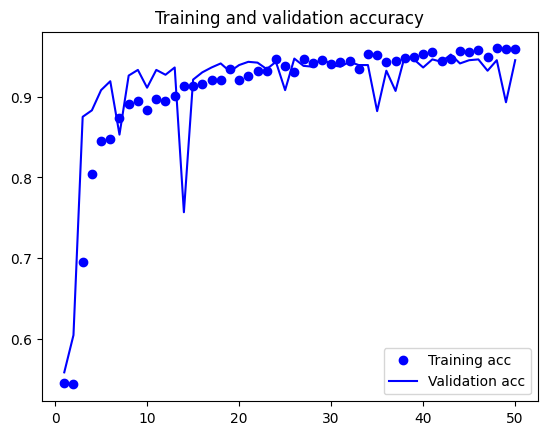

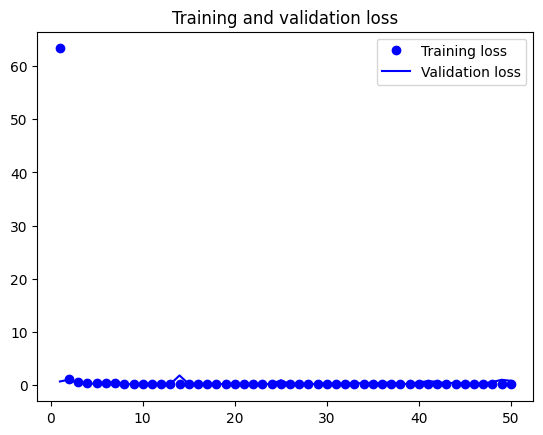

In [38]:
import matplotlib.pyplot as plt
%matplotlib inline

acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

These curves look noisy. To make them more readable, you can smooth them by replacing every loss and accuracy with exponential moving averages of these quantities.

Here’s a trivial utility function to do this

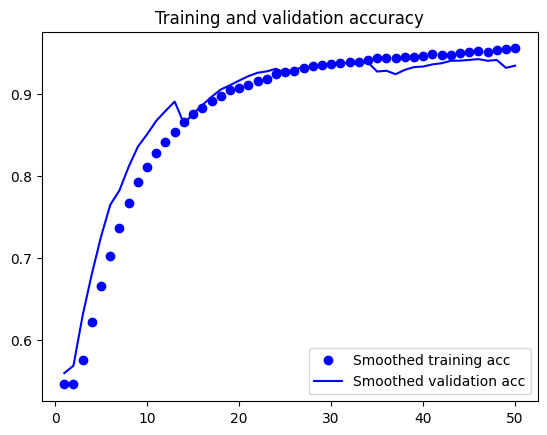

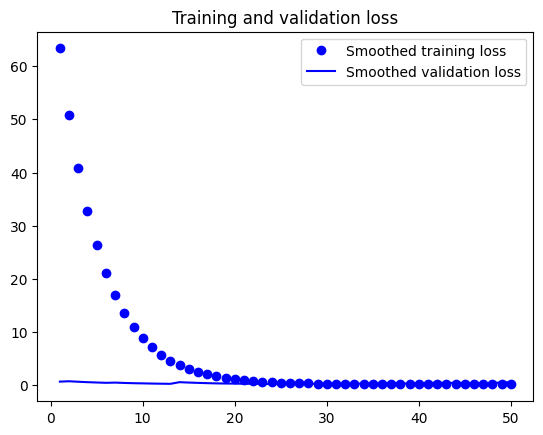

In [39]:
def smooth_curve(points, factor=0.8):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

plt.plot(epochs,
        smooth_curve(acc), 'bo', label='Smoothed training acc')
plt.plot(epochs,
        smooth_curve(val_acc), 'b', label='Smoothed validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

plt.plot(epochs,
        smooth_curve(loss), 'bo', label='Smoothed training loss')
plt.plot(epochs,
        smooth_curve(val_loss), 'b', label='Smoothed validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

The validation accuracy curve look much cleaner. You’re seeing a nice $4\%$ absolute improvement in accuracy, from about $90\%$ to $94+\%$.

Note that the loss curve doesn’t show any real improvement (in fact, it’s deteriorating). You may wonder, how could accuracy stay stable or improve if the loss isn’t decreasing? The answer is simple: what you display is an average of pointwise loss values; but what matters for accuracy is the distribution of the loss values, not their average, because accuracy is the result of a binary thresholding of the class probability predicted by the model. The model may still be improving even if this isn’t reflected in the average loss.

You can now finally evaluate this model on the test data:

In [40]:
#test_generator = test_datagen.flow_from_directory(
#    test_dir,
#    target_size=(150, 150),
#    batch_size=20,
#    class_mode='binary')

#test_loss, test_acc = model.evaluate_generator(test_generator, steps=50)
#print('test acc:', test_acc)

<div class="alert alert-block alert-success">

### ⚠️ Checkpoint ⚠️

**Recap of Model Performance**
1. Small CNN (70-73%)
2. Small CNN + Data Augmentation and Dropout (83%)
3. VGG16 with frozen Dense Layer (90%)
4. VGG16 with frozen Dense Layer trained end to end with Data Augmentation (90%)
5. VGG16 with frozen base (except 'block5_conv1') and trainable Dense Layer (94+%)

Here you get a test accuracy of 94%. You managed to reach this result using only a small fraction of the training data available (about 10%). There is a huge difference between being able to train on 20,000 samples compared to 2,000 samples and this result will already be among the top 5 in 2015!
</div>

In [50]:
model.save(MODEL_DIR + "VGG16_finetuned.h5")

In [51]:
# serialize model to JSON
model_json = model.to_json()
with open(MODEL_DIR + "model.json", "w") as json_file:
    json_file.write(model_json)
# serialize weights to HDF5
model.save_weights(MODEL_DIR + "model.h5")
print("Saved model to disk")

Saved model to disk


In [52]:
with open(MODEL_DIR + 'VGG16_finetuned_model_architecture2.json', 'w') as f:
    f.write(model.to_json())

In [53]:
from tensorflow.keras.models import model_from_json

# Model reconstruction from JSON file
with open(MODEL_DIR +'VGG16_finetuned_model_architecture2.json', 'r') as f:
    model = model_from_json(f.read())

In [54]:
from tensorflow.keras.models import load_model
model.load_weights(MODEL_DIR + "/VGG16_finetuned.h5")

# Step 6: Prototyping
Let's have some intution on our result. We get a random image from the net of cats and dogs and see if it can classify it using the model here:

In [55]:
from PIL import Image

from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input
import numpy as np

img_path =  IMG_DIR + '/cat.jpg'

img = image.load_img(img_path, target_size=(150, 150))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

#CAT=0, DOG=1
Prediction = model.predict(x)
if Prediction >= .5:
    print("DOG")
else:
    print("CAT")

print(Prediction)

img = Image.open(img_path)
img

Output hidden; open in https://colab.research.google.com to view.

# Summary

Here’s what you should take away from the exercises we had:

*  CNN or Convnets are the best machine-learning models for computer vision tasks. It is possible to train one from scratch, even on a very small dataset, with decent results.
*   Overfitting will be the main issue on a small dataset. Data augmentation is a powerful way to fight overfitting when working with image data.    
* Reusing an existing convent on a new dataset via feature extraction is easy. This is a valuable technique for working with small image datasets.   
* In addition to feature extraction, you can use fine-tuning, which adapts to a new problem, such as some of the representations previously learned by an existing model. This pushes performance a bit further. Now, you have a solid set of tools for dealing with image classification problems, particularly small datasets.   

# Good job!
You have learned about one of the most successful and widely used machine learning models for image classification! You should now be ready to start conceptualizing your main project.

Unfortunately, there are two major drawbacks with VGG:
1. It is painfully slow to train.
2. The network architecture weights themselves are quite large (in terms of disk/bandwidth).

Due to its depth and number of fully-connected nodes, VGG is over 533MB for VGG16 and 574MB for VGG19. This makes deploying VGG a tiresome task. We still use VGG in many deep learning image classification problems; however, smaller network architectures are often more desirable (such as SqueezeNet, GoogLeNet, etc.).

<div class="alert alert-block alert-danger">

# Homework 1
See ALICE for submission details.

1. Implement **VGG19**, compare the results with VGG16. Compare the best models for each type.

2. Plot the **test accuracy** as you increase the training samples from 500, 1000, 2000, 5000, 10000, 15000 **without** data augmentation (use only 30 epochs per run). Provide an analysis.
  - Note: The [Dogs vs. Cats competition](https://www.kaggle.com/c/dogs-vs-cats/data) contains 25,000 images in the training set, which you can download on Kaggle. What we have worked on so far is a pre-selected subset of this.

3. Implement **Xception** using the same data set (2000 samples for training, 1000 each for test and validation). Compare the architecture and accuracy with the results discussed here.

![Xception](https://user-images.githubusercontent.com/25600601/134777628-06b7b6dd-6bba-4c15-85ca-b735c2f7054f.png)
</div>

# Appendix. ImageNet
Source: https://en.wikipedia.org/wiki/ImageNet

The ImageNet project is a large visual database designed for use in visual object recognition software research. Over 14 million URLs of images have been hand-annotated by ImageNet to indicate what objects are pictured; in at least one million of the images, bounding boxes are also provided. ImageNet contains over 20 thousand categories;a typical category, such as "balloon" or "strawberry", contains several hundred images. The database of annotations of third-party image URLs is freely available directly from ImageNet; however, the actual images are not owned by ImageNet. Since 2010, the ImageNet project runs an annual software contest, the ImageNet Large Scale Visual Recognition Challenge (ILSVRC), where software programs compete to correctly classify and detect objects and scenes. The ImageNet Challenge uses a "trimmed" list of one thousand non-overlapping classes.

A dramatic 2012 breakthrough in solving the ImageNet Challenge is widely considered to be the beginning of the deep learning revolution of the 2010s: "Suddenly people started to pay attention, not just within the AI community but across the technology industry as a whole.


## ImageNet Challenge
Since 2010, the annual ImageNet Large Scale Visual Recognition Challenge (ILSVRC) is a competition where research teams evaluate their algorithms on the given data set, and compete to achieve higher accuracy on several visual recognition tasks. The ILSVRC aims to "follow in the footsteps" of the smaller-scale PASCAL VOC challenge, established in 2005, which contained only about 20,000 images and twenty object classes. The ILSVRC uses a "trimmed" list of only 1000 image categories or "classes", including 90 of the 120 dog breeds classified by the full ImageNet schema. The 2010s saw dramatic progress in image processing. Around 2011, a good ILSVRC classification error rate was 25%. In 2012, a deep convolutional neural net achieved 16%; in the next couple of years, error rates fell to a few percent.  While the 2012 breakthrough "combined pieces that were all there before", the dramatic quantitative improvement marked the start of an industry-wide artificial intelligence boom.By 2015, researchers reported that software exceeded human ability at the narrow ILSVRC tasks. However, as one of the challenge's organizers, Olga Russakovsky, pointed out in 2015, the programs only have to identify images as belonging to one of a thousand categories; humans can recognize a larger number of categories, and also (unlike the programs) can judge the context of an image.

By 2014, over fifty institutions participated in the ILSVRC. In 2015, Baidu scientists were banned for a year for using different accounts to greatly exceed the specified limit of two submissions per week. Baidu later stated that it fired the team leader involved and that it would establish a scientific advisory panel.

In 2017, 29 of 38 competing teams got less than 5% wrong. In 2017 ImageNet stated it would roll out a new, much more difficult, challenge in 2018 that involves classifying 3D objects using natural language. Because creating 3D data is more costly than annotating a pre-existing 2D image, the dataset is expected to be smaller. The applications of progress in this area would range from robotic navigation to augmented reality.

![imagenet_history](https://user-images.githubusercontent.com/25600601/134777794-fc0e42cc-df07-4b65-a276-fb3dba8e27a5.png)

## 1000 Categories of ImageNet

In [57]:
import pandas as pd
df = pd.read_fwf(DATA_DIR + 'map_clsloc.txt', header = None)
df

,0,1
0,n02119789,1 kit_fox
1,n02100735,2 English_setter
2,n02110185,3 Siberian_husky
3,n02096294,4 Australian_terrier
4,n02102040,5 English_springer
...,...,...
995,n03063599,996 coffee_mug
996,n04116512,997 rubber_eraser
997,n04325704,998 stole
998,n07831146,999 carbonara
